In [18]:
import json
import os
from pathlib import Path

import ee
import ee.deserializer
import geemap
import matplotlib.pyplot as plt
import pandas as pd

from nu_afolu.constants import LABEL_LIST

In [2]:
ZONE = "01.1.01"

In [3]:
ee.Initialize()

In [4]:
out_path = Path(os.environ["OUT_PATH"])

In [5]:
label_map = dict(enumerate(LABEL_LIST, start=1))

In [6]:
with (out_path / "bbox" / "ee" / f"{ZONE}.json").open() as f:
    bbox: ee.Geometry = ee.deserializer.decode(json.load(f))

with (out_path / "area_raster" / f"{ZONE}.json").open() as f:
    area_raster: ee.Image = ee.deserializer.decode(json.load(f))
    area_raster = area_raster.updateMask(area_raster.neq(ee.Number(0)))

with (out_path / "transition_raster" / f"{ZONE}.json").open() as f:
    transition_raster: ee.Image = ee.deserializer.decode(json.load(f)).clip(bbox)
    transition_raster = transition_raster.updateMask(
        transition_raster.neq(ee.Number(0))
    )

In [36]:
result["2000"]

{'1': 413858.43529411743,
 '10': 250453.7999999999,
 '11': 2683.427450980392,
 '2': 3392.458823529412,
 '5': 52216.325490196075,
 '6': 387544.15686274506,
 '7': 696,
 '8': 50002.65098039213,
 '9': 142686.8862745098}

In [40]:
area_raster.multiply(ee.Image.pixelArea()).reduceRegion(ee.Reducer.sum().group(1, groupName="class"), bbox, 30, maxPixels=int(1e10)).getInfo()

EEException: ReduceRegion.AggregationContainer: Need 2 bands for Reducer.group(Reducer.sum), <Image<[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]>> has 22.

In [7]:
col_chen = ee.ImageCollection(
    "projects/sat-io/open-datasets/FUTURE-URBAN-LAND/CHEN_2020_2100"
)

In [27]:
def reduce_ssp_col(col: ee.ImageCollection, *, scale: float) -> pd.DataFrame:
    reduced: ee.FeatureCollection = col.map(
        lambda img: ee.Feature(
            bbox,
            img.eq(ee.Number(2))
            .multiply(ee.Image.pixelArea())
            .reduceRegion(ee.Reducer.sum(), geometry=bbox, scale=scale),
        )
    )

    collected: dict[str, list[float]] = {}
    for suffix in range(1, 6):
        property_name = f"SSP{suffix}"
        arr = reduced.aggregate_array(property_name).getInfo()
        if not isinstance(arr, list):
            err = f"Expected list for property {property_name}, got {type(arr)}"
            raise TypeError(err)
        collected[property_name] = arr

    return pd.DataFrame(collected, index=[str(year) for year in range(2020, 2101, 10)])


df_chen = reduce_ssp_col(col_chen, scale=1000)

<Axes: >

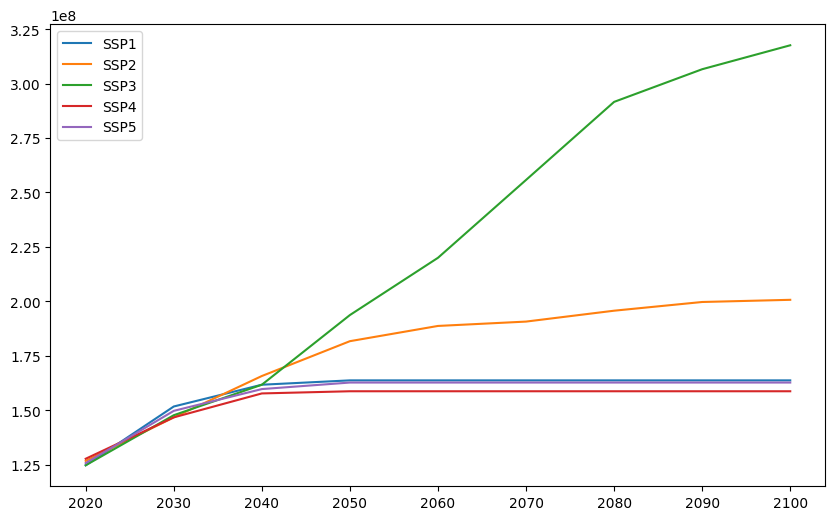

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
df_chen.plot(ax=ax)

In [ ]:
urban_areas = (
    area_raster.eq(ee.Number(9))
    .multiply(ee.Image.pixelArea())
    .reduceRegion(ee.Reducer.sum(), geometry=bbox, scale=30, maxPixels=int(1e10))
    .getInfo()
)

In [25]:
m = geemap.Map()
m.addLayer(
    area_raster.eq(ee.Number(9)).selfMask(), {"palette": "red", "bands": ["2020"]}
)
m.addLayer(test, {"palette": "blue", "bands": ["SSP1"]})
m.centerObject(bbox)
m

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…